# TFM IGNACIO FERNANDEZ
**DATASET:** https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling



## 0. Importar librerías

In [2]:
import pandas as pd
from IPython.display import display, HTML
import os

## OBJETIVO: 
El objetivo de este proyecto es diseñar y construir un sistema predictivo–explicable capaz de anticipar el abandono de Clientes en el sector bancario y de interpretar los factores que influyen en dicha decisión. Para ello, se desarrollan y comparan diferentes modelos de Machine Learning orientados a identificar de forma temprana a los Clientes con mayor probabilidad de churn y se incorporan técnicas de explicabilidad con el objetivo de comprender el porqué de cada predicción. 

### Enfoque predictivo

![Enfoque predictivo](TFM%20Images/Enfoque%20predictivo.png)

### Enfoque explicativo

![Enfoque explicativo](TFM%20Images/Enfoque%20explicativo.png)

 A la hora de definir su desarrollo técnico se toma como base el esquema general de las distintas fases para diseñar e implementar modelos de Machine Learning adaptado al problema que en este trabajo se resuelve.

## Esquema general de las distintas fases para diseñar e implementar modelos de Machine Learning 

![Esquema general modelos machine learning](TFM%20Images/Esquema%20general%20modelos%20machine%20learning.png)

## Adaptación: Pipeline completo del desarrollo técnico:

![Pipeline completo](TFM%20Images/Pipeline%20completo.png)

## 1. ANALISIS DEL DATASET

## 1.1 Descarga del Dataset desde Kaggle



In [3]:
CSV_PATH = "Churn_Modelling.csv"

if os.path.exists(CSV_PATH):
    print(f"Archivo encontrado: {CSV_PATH}")
else:
    print("Archivo no encontrado localmente. Intentando descarga con Kaggle API...")
    try:
        import kaggle
        kaggle.api.authenticate()
        kaggle.api.dataset_download_files(
            "shrutimechlearn/churn-modelling",
            path=".",
            unzip=True
        )
        print("Dataset descargado correctamente.")
    except Exception as e:
        print(f"No se pudo descargar automáticamente: {e}")
        print()
        print("Descarga manual:")
        print("   1. Ve a: https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling")
        print("   2. Haz clic en 'Download'")
        print("   3. Descomprime y copia 'Churn_Modelling.csv' en esta carpeta:")
        print(f"      {os.path.abspath('.')}")

Archivo encontrado: Churn_Modelling.csv


## 1.2. Carga y visualización del Dataset 

In [4]:
df = pd.read_csv(CSV_PATH)

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas\n")

display(df.head(20))

Dataset cargado: 10000 filas x 14 columnas



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


## 1.3. EDA

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


![variables1](TFM%20Images/variables1.png)

In [6]:
print("=" * 60)
print("COLUMNAS Y TIPOS DE DATOS")
print("=" * 60)
print(df.dtypes.to_string())

print("\n" + "=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
print(df.isnull().sum().to_string())

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE GENDER")
print("=" * 60)
print(df["Gender"].value_counts(dropna=False).to_string())

print("\n" + "=" * 60)
print("DISTRIBUCIÓN DE GEOGRAPHY")
print("=" * 60)
print(df["Geography"].value_counts(dropna=False).to_string())

print("\n")
print("Distribución de la variable objetivo 'Exited' (Churn):")
print(df["Exited"].value_counts().rename({0: "No abandonó (0)", 1: "Abandonó (1)"}).to_string())

COLUMNAS Y TIPOS DE DATOS
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64

VALORES NULOS POR COLUMNA
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0

ESTADÍSTICAS DESCRIPTIVAS


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000



DISTRIBUCIÓN DE GENDER
Gender
Male      5457
Female    4543

DISTRIBUCIÓN DE GEOGRAPHY
Geography
France     5014
Germany    2509
Spain      2477


Distribución de la variable objetivo 'Exited' (Churn):
Exited
No abandonó (0)    7963
Abandonó (1)       2037


### Nulos

In [7]:
null_counts = df.isnull().sum().reset_index()
null_counts.columns = ["Columna", "Valores Nulos"]
display(null_counts)

,Columna,Valores Nulos
0,RowNumber,0
1,CustomerId,0
2,Surname,0
3,CreditScore,0
4,Geography,0
5,Gender,0
6,Age,0
7,Tenure,0
8,Balance,0
9,NumOfProducts,0


### Valores unicos de cada columna categórica

FRECUENCIAS Y PROPORCIONES DE VARIABLES CATEGÓRICAS

------------------------------------------------------------
Variable: Surname
------------------------------------------------------------


C:\Users\ignac\AppData\Local\Temp\ipykernel_42972\864226411.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


,Frecuencia,Proporción (%)
Surname,,
Smith,32,0.32
Scott,29,0.29
Martin,29,0.29
Walker,28,0.28
Brown,26,0.26
...,...,...
Salinas,1,0.01
Cleveland,1,0.01
Kashiwagi,1,0.01



------------------------------------------------------------
Variable: Geography
------------------------------------------------------------


,Frecuencia,Proporción (%)
Geography,,
France,5014,50.14
Germany,2509,25.09
Spain,2477,24.77


...


------------------------------------------------------------
Variable: IsActiveMember
------------------------------------------------------------


,Frecuencia,Proporción (%)
IsActiveMember,,
1,5151,51.51
0,4849,48.49



------------------------------------------------------------
Variable: Exited
------------------------------------------------------------


,Frecuencia,Proporción (%)
Exited,,
0,7963,79.63
1,2037,20.37



GRÁFICOS DEL REPARTO DE VARIABLES


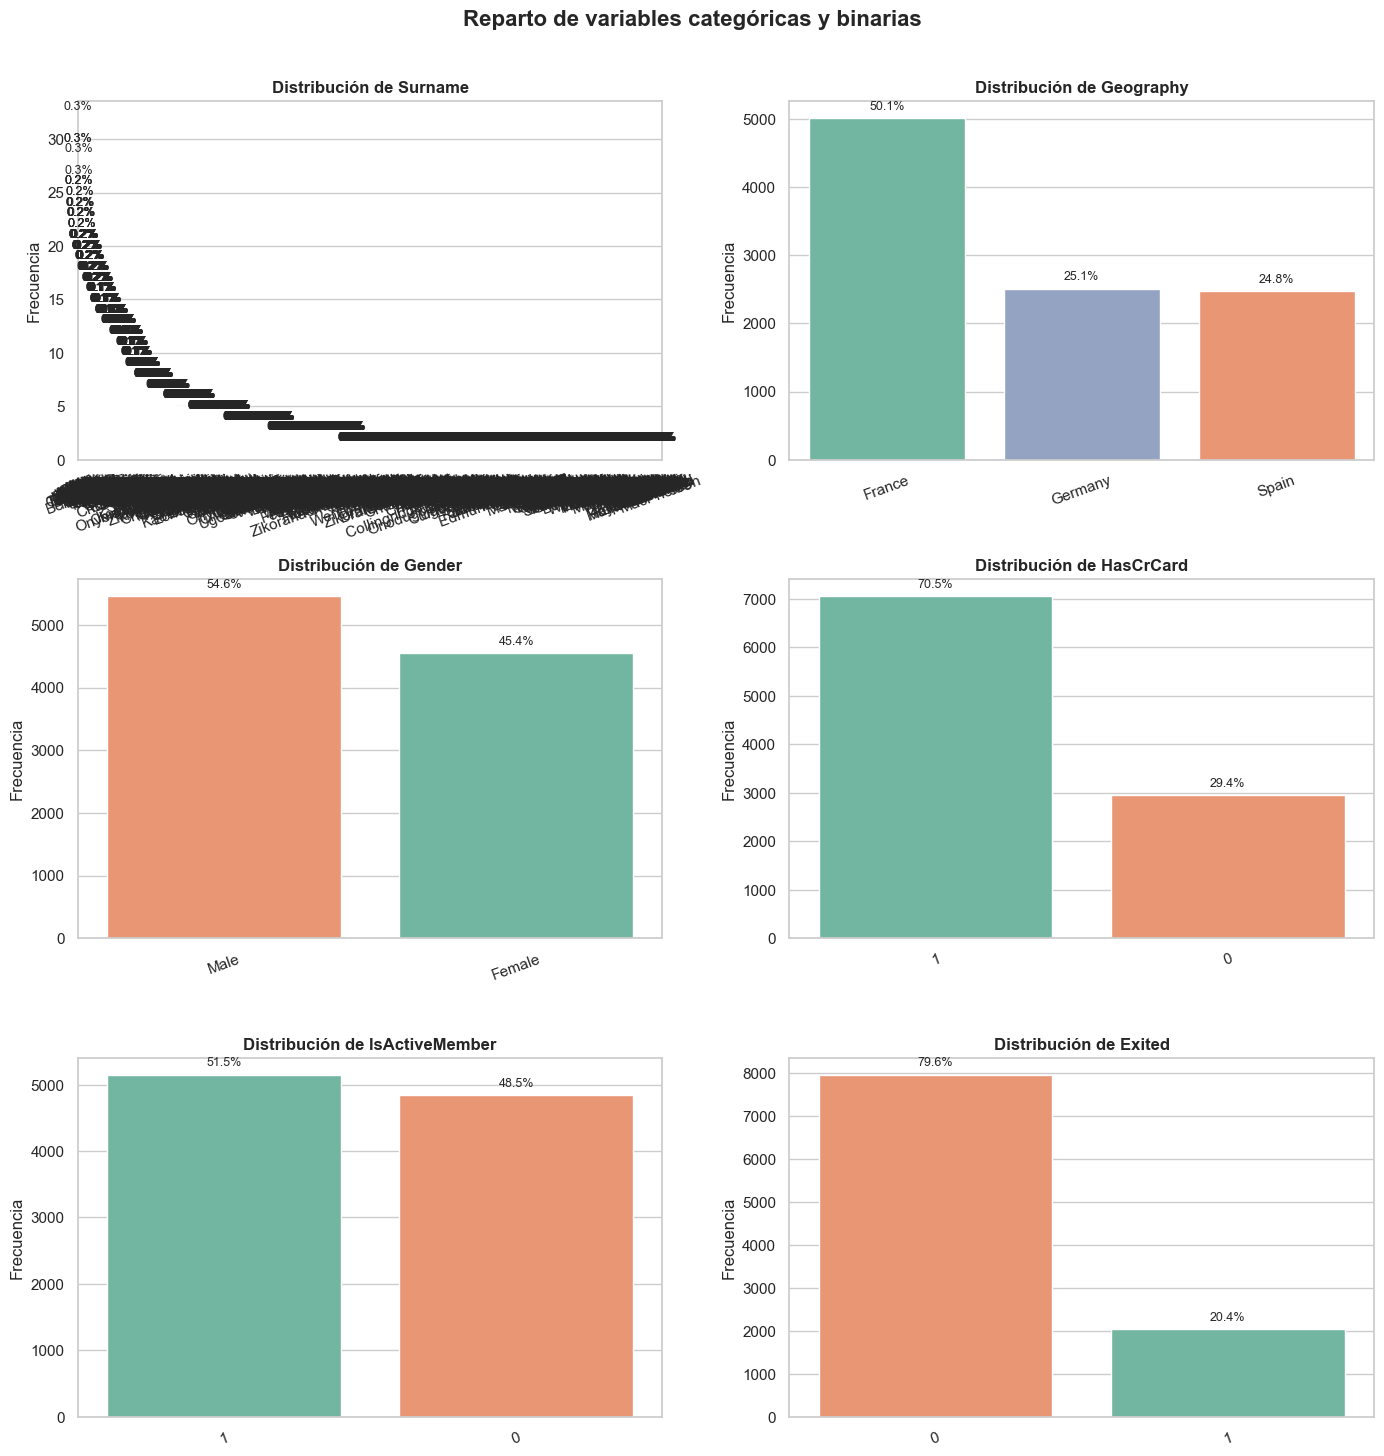

In [8]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("FRECUENCIAS Y PROPORCIONES DE VARIABLES CATEGÓRICAS")
print("=" * 60)

cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

if not cat_cols:
    print("No se encontraron columnas categóricas en este punto del análisis.")
else:
    for col in cat_cols:
        print("\n" + "-" * 60)
        print(f"Variable: {col}")
        print("-" * 60)

        counts = df[col].value_counts(dropna=False)
        props = df[col].value_counts(dropna=False, normalize=True).mul(100).round(2)

        resumen = pd.DataFrame({
            "Frecuencia": counts,
            "Proporción (%)": props
        })
        display(resumen)

print("\n" + "=" * 60)
print("FRECUENCIAS Y PROPORCIONES DE VARIABLES BINARIAS")
print("=" * 60)

binary_cols = ["HasCrCard", "IsActiveMember", "Exited"]

for col in binary_cols:
    if col in df.columns:
        print("\n" + "-" * 60)
        print(f"Variable: {col}")
        print("-" * 60)

        counts = df[col].value_counts(dropna=False)
        props = df[col].value_counts(dropna=False, normalize=True).mul(100).round(2)

        resumen = pd.DataFrame({
            "Frecuencia": counts,
            "Proporción (%)": props
        })
        display(resumen)

print("\n" + "=" * 60)
print("GRÁFICOS DEL REPARTO DE VARIABLES")
print("=" * 60)

plot_cols = cat_cols + [c for c in binary_cols if c in df.columns and c not in cat_cols]

if not plot_cols:
    print("No hay variables para graficar en este punto del análisis.")
else:
    sns.set_theme(style="whitegrid")
    n_cols = 2
    n_rows = math.ceil(len(plot_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.8 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        series = df[col].astype(str)
        order = series.value_counts(dropna=False).index.tolist()
        sns.countplot(x=series, order=order, ax=ax, palette="Set2", hue=series, legend=False)

        total = len(series)
        for p in ax.patches:
            h = p.get_height()
            pct = 100 * h / total if total else 0
            ax.annotate(f"{pct:.1f}%",
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=9, xytext=(0, 4), textcoords="offset points")

        ax.set_title(f"Distribución de {col}", fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")
        ax.tick_params(axis="x", rotation=20)

    for j in range(len(plot_cols), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Reparto de variables categóricas y binarias", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

In [9]:
print("\n")
print("Valores únicos en columnas categóricas:")
for col in ["Gender", "Geography"]:
    unique_vals = df[col].unique()
    print(f"- {col}: {unique_vals}")
    print("\n")




Valores únicos en columnas categóricas:
- Gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str


- Geography: <StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str




In [10]:
### total de cada valor unico de las columnas categoricas
print("\n")
for col in ["Gender", "Geography"]:
    print(f"Distribución de '{col}':")
    print(df[col].value_counts().to_string())
    print("\n")



Distribución de 'Gender':
Gender
Male      5457
Female    4543


Distribución de 'Geography':
Geography
France     5014
Germany    2509
Spain      2477




### OUTLIERS

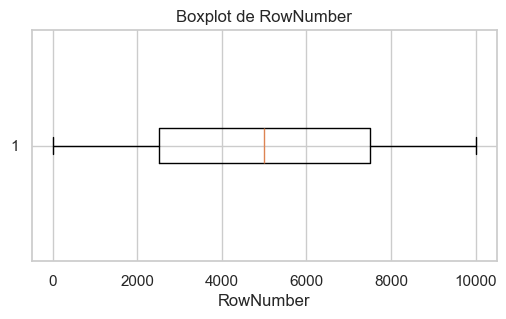

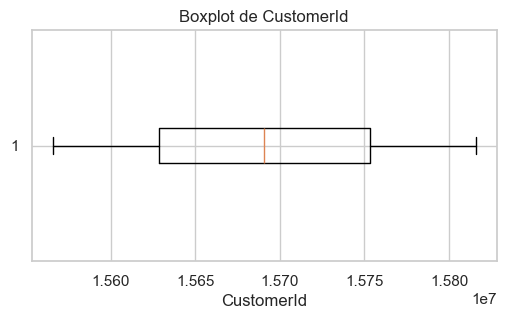

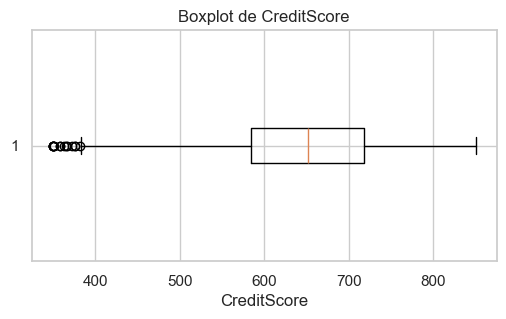

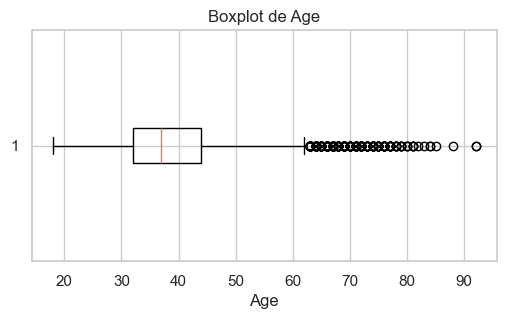

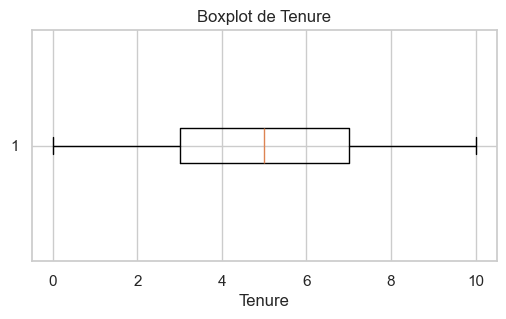

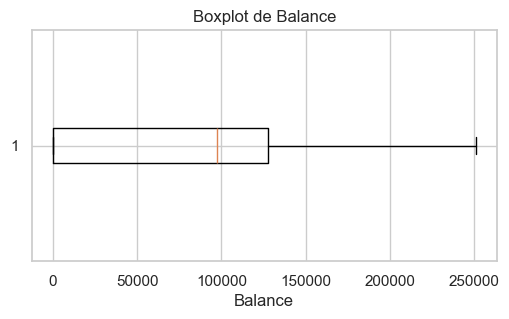

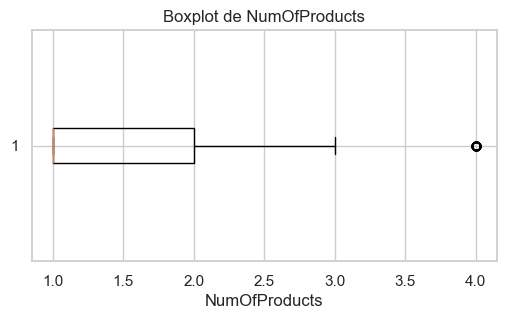

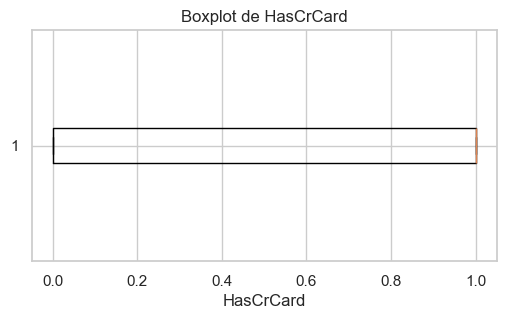

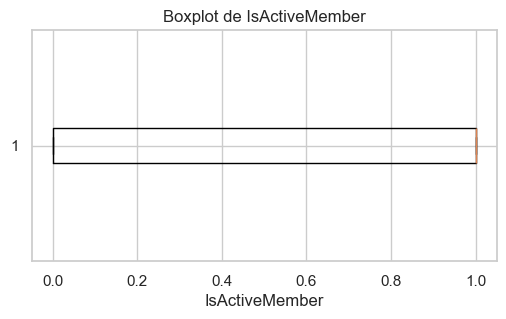

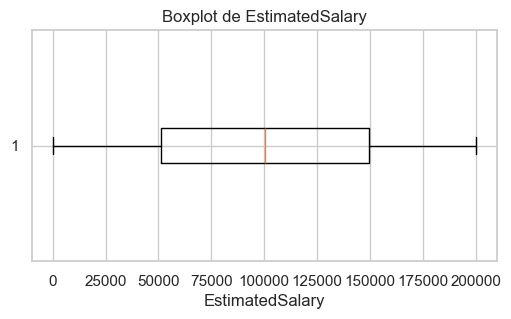

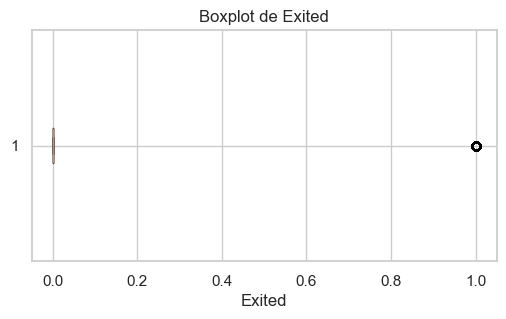

In [11]:
import matplotlib.pyplot as plt
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

In [12]:
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return len(series[(series < lower_bound) | (series > upper_bound)])

print("Número de outliers por columna (método IQR):")
print("=" * 45)
for col in ["CreditScore", "Age", "NumOfProducts"]:
    n = count_outliers(df[col])
    print(f"  {col:<20} : {n} outliers")


Número de outliers por columna (método IQR):
  CreditScore          : 15 outliers
  Age                  : 359 outliers
  NumOfProducts        : 60 outliers


### DISTRIBUCIONES

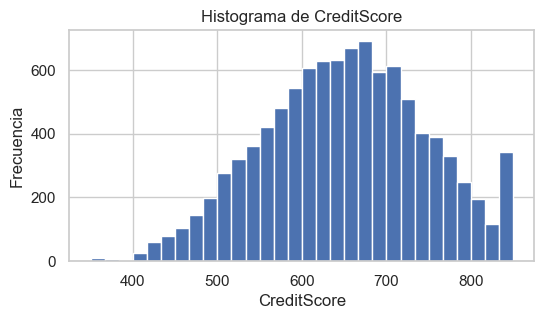

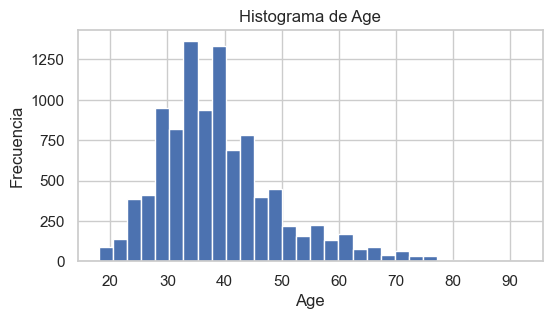

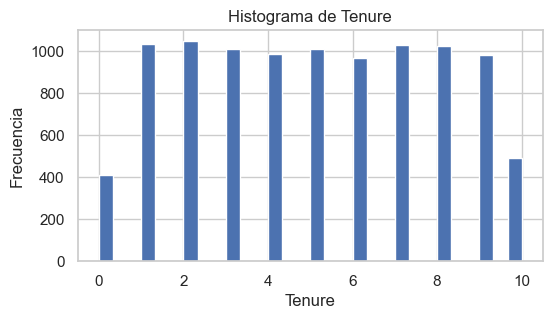

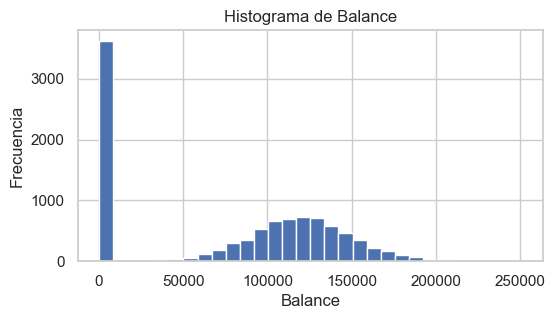

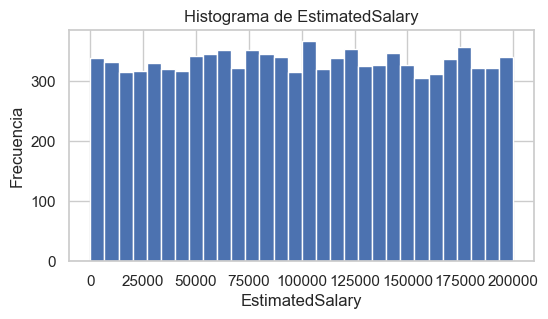

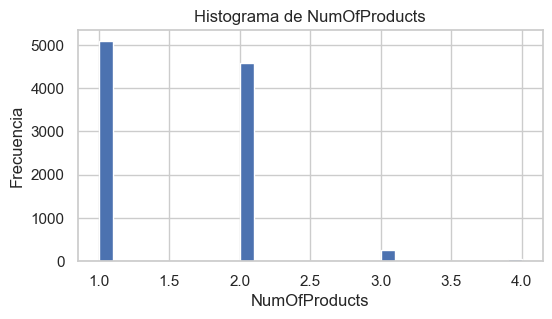

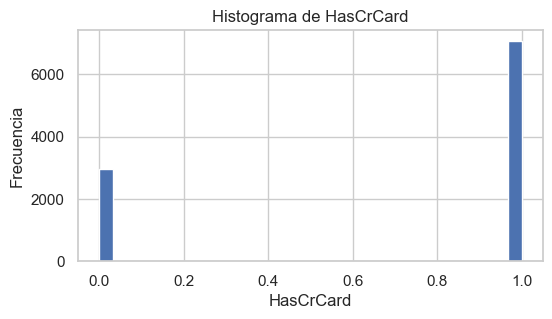

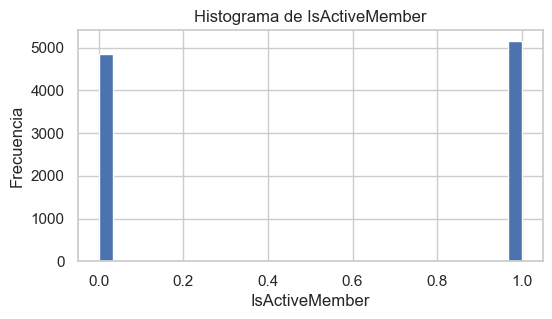

In [13]:
### DISTRIBUCIÓN DE variables numéricas: CreditScore, Age, Tenure, Balance, EstimatedSalary, NumOfProducts, HasCrCard, IsActiveMember 
import matplotlib.pyplot as plt
cols_to_plot = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary", "NumOfProducts", "HasCrCard", "IsActiveMember"]
for col in cols_to_plot:
    plt.figure(figsize=(6, 3))
    plt.hist(df[col], bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

### RELACIONES DE CADA VARIABLE CON LA VARIABLE OBJETIVO:

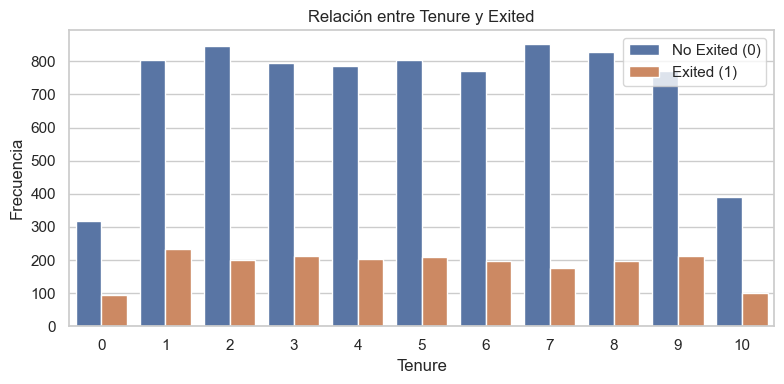

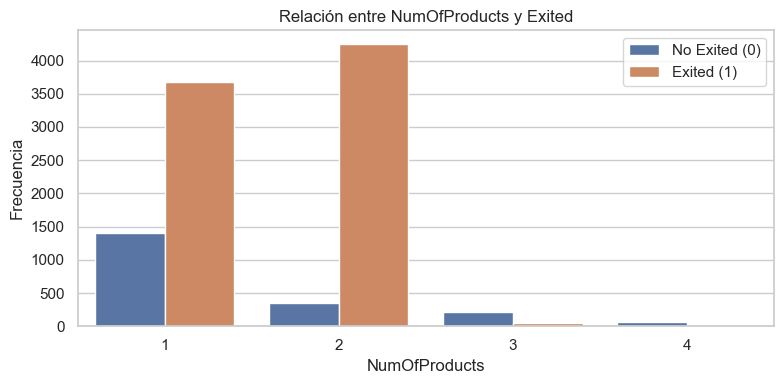

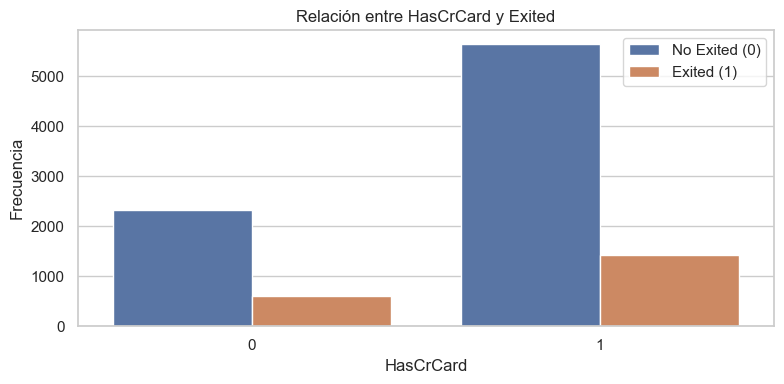

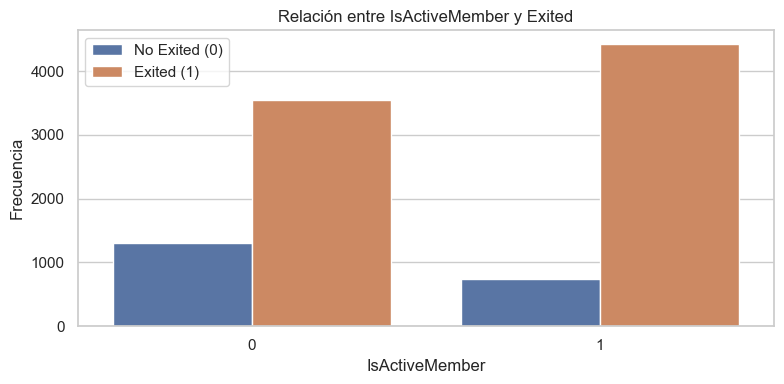

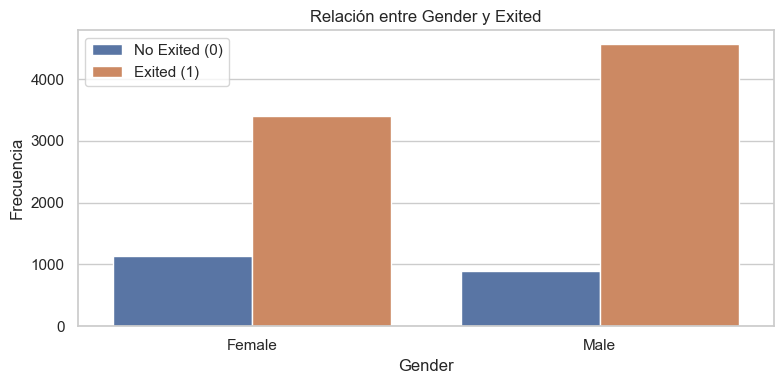

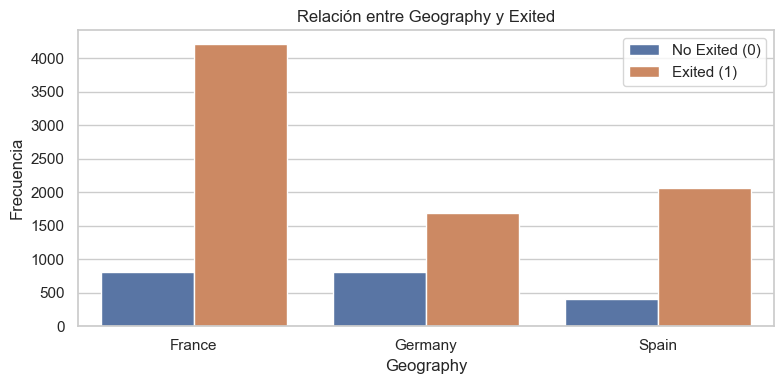

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["Tenure", "NumOfProducts", "HasCrCard", "IsActiveMember", "Gender", "Geography"]

for col in cols:
    fig, ax = plt.subplots(figsize=(8, 4))

    # Para columnas categóricas de texto respetamos el orden de frecuencia; para numéricas orden natural.
    if df[col].dtype == "object":
        order = df[col].value_counts().index.tolist()
    else:
        order = sorted(df[col].unique())

    sns.countplot(x=col, hue=df["Exited"].astype(str),
                  data=df, order=order, ax=ax)
    ax.set_title(f"Relación entre {col} y Exited")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ["No Exited (0)", "Exited (1)"])
    plt.tight_layout()
    plt.show()

### CORRELACIONES



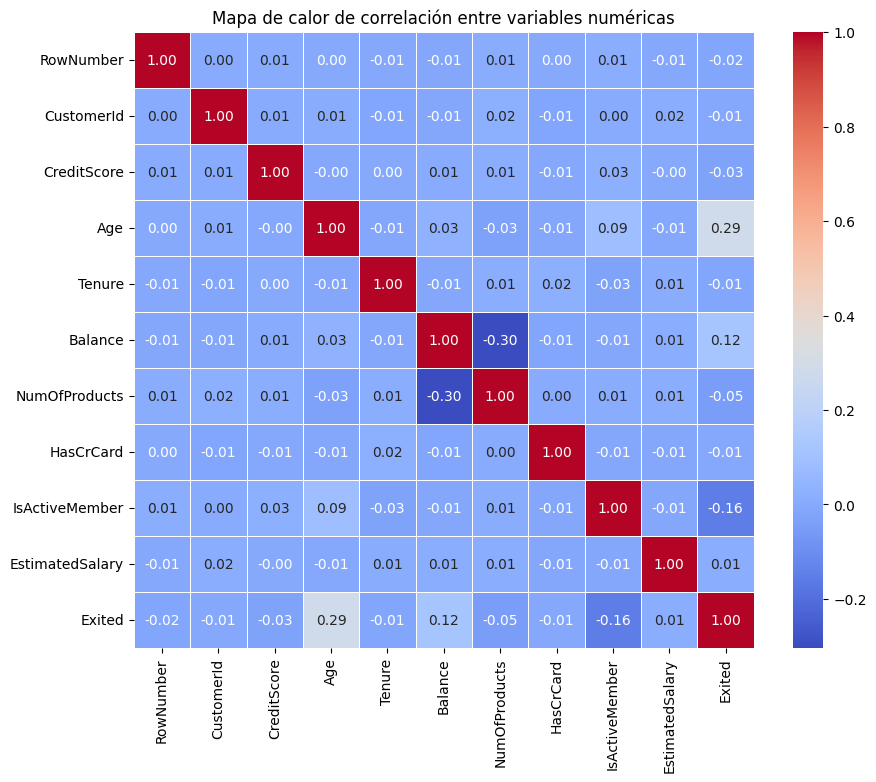

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de calor de correlación entre variables numéricas")
plt.show()

## 2. LIMPIEZA DE DATOS, PREPROCESADO E INGENIERIA DE CARACTERÍSTICAS


![Limpieza de datos](TFM%20Images/Limpieza%20de%20datos.png)

### ELIMINO APELLIDOS + ELIMINO ROWNUMBER Y CUSTOMER ID

In [ ]:
# Recarga desde CSV para garantizar estado limpio al inicio del preprocesado
df = pd.read_csv(CSV_PATH)

if "Surname" in df.columns:
    df.drop(columns=["Surname"], inplace=True)
    print("✅ Columna 'Surname' eliminada para proteger la privacidad de los clientes.")


✅ Columna 'Surname' eliminada para proteger la privacidad de los clientes.


In [16]:
### ME CARGO ROW NUMBER Y CUSTMER ID PORQUE NO APORTAN NADA AL MODELO
if "RowNumber" in df.columns:
    df.drop(columns=["RowNumber"], inplace=True)
if "CustomerId" in df.columns:
    df.drop(columns=["CustomerId"], inplace=True)
print("✅ Columnas 'RowNumber' y 'CustomerId' eliminadas para simplificar el modelo.")


✅ Columnas 'RowNumber' y 'CustomerId' eliminadas para simplificar el modelo.


### COMPROBACIÓN

In [17]:
print("\n" + "=" * 60)
print("DATASET DESPUÉS DE LA LIMPIEZA Y EXPLORACIÓN INICIAL")
print("=" * 60)
display(df.head(20))


DATASET DESPUÉS DE LA LIMPIEZA Y EXPLORACIÓN INICIAL


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


### ONE HOT ENCODING DE VARIABLES CATEGÓRICAS (Gender y Geography)


In [ ]:
### ONE HOT ENCODING DE LAS COLUMNNAS GENDER Y GEOGRAPHY. ELIMINAMOS LAS COLUMNAS ORIGINALES Y AÑADIMOS LAS NUEVAS CON LOS NOMBRES DE LAS CATEGORÍAS Y CON VALORES 0,1 PARA GENDDER MALE, GENFER FEMAELE, GEOGRAPHY FRANCE, GEOGRAPHY SPAIN, GEOGRAPHY GERMANY
df_encoded = pd.get_dummies(df, columns=["Gender", "Geography"], prefix=["Gender", "Geography"], dtype=int)

# 'Exited' al final (variable objetivo) pa que sea más fácil de identificar y separar del resto de las características
cols = [c for c in df_encoded.columns if c != "Exited"] + ["Exited"]
df_encoded = df_encoded[cols]

# Reasignar a df para que el resto del notebook no necesite cambios
df = df_encoded

print("✅ One-hot encoding aplicado a las columnas 'Gender' y 'Geography'.")
print(f"Nuevo número de columnas después del encoding: {df.shape[1]}")

✅ One-hot encoding aplicado a las columnas 'Gender' y 'Geography'.
Nuevo número de columnas después del encoding: 14


In [19]:
print("\n" + "=" * 60)
print("DATASET DESPUÉS DEL ONE-HOT ENCODING")
print("=" * 60)
display(df_encoded.head(20))


DATASET DESPUÉS DEL ONE-HOT ENCODING


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain,Exited
0,619,42,2,0.00,1,1,1,101348.88,1,0,1,0,0,1
1,608,41,1,83807.86,1,0,1,112542.58,1,0,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,1,0,0,1
3,699,39,1,0.00,2,0,0,93826.63,1,0,1,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,1,0,0,0,1,0
5,645,44,8,113755.78,2,1,0,149756.71,0,1,0,0,1,1
6,822,50,7,0.00,2,1,1,10062.80,0,1,1,0,0,0
7,376,29,4,115046.74,4,1,0,119346.88,1,0,0,1,0,1
8,501,44,4,142051.07,2,0,1,74940.50,0,1,1,0,0,0
9,684,27,2,134603.88,1,1,1,71725.73,0,1,1,0,0,0


### ESTANDARIZACION.

In [20]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = ["CreditScore", "Balance", "EstimatedSalary", "Age", "Tenure", "NumOfProducts"]
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print("✅ Columnas estandarizadas:", cols_to_scale)

✅ Columnas estandarizadas: ['CreditScore', 'Balance', 'EstimatedSalary', 'Age', 'Tenure', 'NumOfProducts']


In [21]:
display(df.head(20))

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain,Exited
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,0,1,0,0,1
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,1,0,0,0,1,0
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,0,1,0,0,1
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,1,0,1,0,0,0
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,1,0,0,0,1,0
5,-0.057205,0.484225,1.032908,0.597329,0.807737,1,0,0.863650,0,1,0,0,1,1
6,1.774174,1.056346,0.687130,-1.225848,0.807737,1,1,-1.565487,0,1,1,0,0,0
7,-2.840488,-0.946079,-0.350204,0.618019,4.246377,1,0,0.334854,1,0,0,1,0,1
8,-1.547141,0.484225,-0.350204,1.050820,0.807737,0,1,-0.437329,0,1,1,0,0,0
9,0.346319,-1.136786,-1.041760,0.931463,-0.911583,1,1,-0.493230,0,1,1,0,0,0


### ANALISIS BALANCEO DE LA VARIABLE OBJETIVO EXITED

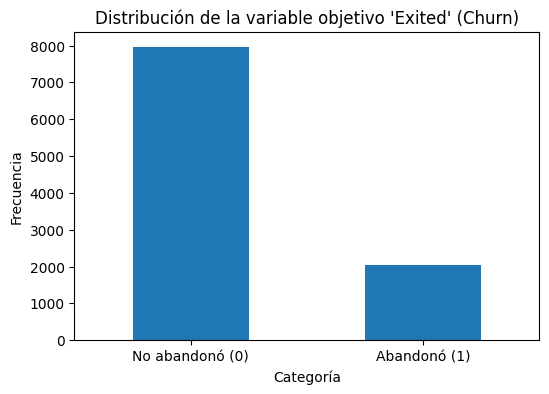



Distribución de la variable objetivo 'Exited' (Churn):
Exited
No abandonó (0)    7963
Abandonó (1)       2037


In [ ]:
### DISTRIBUCIÓN DE LA VARIABLE OBJETIVO 'Exited' (CHURN) 
import matplotlib.pyplot as plt
churn_counts = df["Exited"].value_counts().rename({0: "No abandonó (0)", 1: "Abandonó (1)"})
plt.figure(figsize=(6, 4))
churn_counts.plot(kind="bar")
plt.title("Distribución de la variable objetivo 'Exited' (Churn)")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

print("\n")
print("Distribución de la variable objetivo 'Exited' (Churn):")
print(df["Exited"].value_counts().rename({0: "No abandonó (0)", 1: "Abandonó (1)"}).to_string())


# 3. MODELADO Y 4. EVALUACIÓN

![Modelado 1](TFM%20Images/Modelado1.png)

![Modelado 2](TFM%20Images/Modelado2.png)

![Modelado 3](TFM%20Images/Modelado3.png)

### SPLIT ENTRE TRAIN Y TEST (ACORDARME DE RESPERTAR PROPORCIONES ENTRE CLASES)

In [ ]:
###  REPARTO DEL DATASET EN TRAIN Y TEST CON 0,2 PERO PONIENDO SEMILLA PARA QUE SIEMPRE SEA EL MISMO REPARTO Y PONIENDO LA DISTRIBUCIÓN FUERA COMO HIPERPARÁMETRO
from sklearn.model_selection import train_test_split
X = df.drop("Exited", axis=1)
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Dataset dividido en entrenamiento (80%) y prueba (20%) con semilla fija y estratificación.") 
### COMPROBACIÓN DE LA DISTRIBUCIÓN DE LA VARIABLE OBJETIVO EN LOS CONJUNTOS DE ENTRENAMIENTO Y PRUEBA
print("\nDistribución de 'Exited' en el conjunto de entrenamiento:")
print(y_train.value_counts().rename({0: "No abandonó (0)", 1: "Abandonó (1)"}).to_string())
print("\nDistribución de 'Exited' en el conjunto de prueba:")
print(y_test.value_counts().rename({0: "No abandonó (0)", 1: "Abandonó (1)"}).to_string())

Dataset dividido en entrenamiento (80%) y prueba (20%) con semilla fija y estratificación.

Distribución de 'Exited' en el conjunto de entrenamiento:
Exited
No abandonó (0)    6370
Abandonó (1)       1630

Distribución de 'Exited' en el conjunto de prueba:
Exited
No abandonó (0)    1593
Abandonó (1)        407


## FLUJO HOMOGENEO: IMPLEMENTACIÓN, ENTRENAMIENTO, EVALUACION 

Se entrenan 6 modelos de menor a mayor complejidad usando **GridSearchCV con 5-fold estratificado**.  
Métrica de optimización: **AUC-ROC** (más adecuada para el problema de clasificación CHURM que estoy resolviendo, más adecuada por ej que accuracy dado el desbalanceo de clases).


![Estratificacion](TFM%20Images/Estratificacion.png)

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, roc_auc_score,
                             f1_score, accuracy_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore")

# Diccionario pa acumular los resultados de todos los modelos
results = {}

# Validación cruzada estratificada común a todos los GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Librerías cargadas.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Distribución y_train — 0: {(y_train==0).sum()}  |  1: {(y_train==1).sum()}")

Librerías cargadas.
X_train: (8000, 13)  |  X_test: (2000, 13)
Distribución y_train — 0: 6370  |  1: 1630


# Regresión Logística


── Regresión Logística ──────────────────────────────
Mejores parámetros: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy en test : 0.7200
Precision en test : 0.3945
Recall en test    : 0.7027
F1-Score en test  : 0.5053
AUC-ROC en test   : 0.7771
              precision    recall  f1-score   support

   No Exited       0.91      0.72      0.80      1593
      Exited       0.39      0.70      0.51       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.80      0.72      0.74      2000



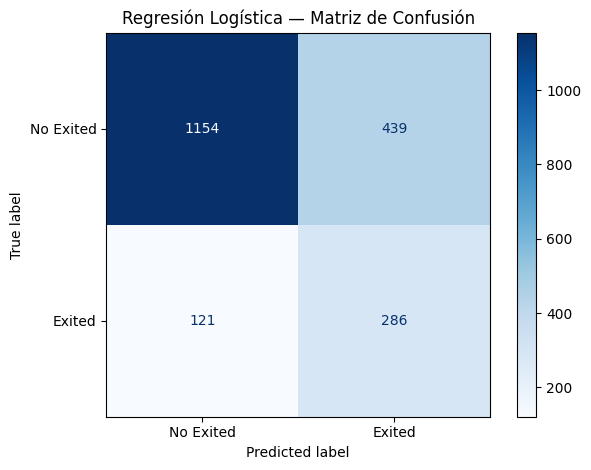

In [39]:
param_grid_lr = {
    "C":            [0.01, 0.1, 1, 10, 100],
    "penalty":      ["l1", "l2"],
    "solver":       ["liblinear"],
    "class_weight": ["balanced"],
    "max_iter":     [1000],
}

gs_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_lr.fit(X_train, y_train)
best_lr = gs_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

results["Regresión Logística"] = {
    "best_params": gs_lr.best_params_,
    "accuracy":    accuracy_score(y_test, y_pred_lr),
    "precision":   precision_score(y_test, y_pred_lr),
    "recall":      recall_score(y_test, y_pred_lr),
    "f1":          f1_score(y_test, y_pred_lr),
    "roc_auc":     roc_auc_score(y_test, y_prob_lr),
}

print("── Regresión Logística ──────────────────────────────")
print("Mejores parámetros:", gs_lr.best_params_)
print(f"Accuracy en test : {results['Regresión Logística']['accuracy']:.4f}")
print(f"Precision en test : {results['Regresión Logística']['precision']:.4f}")
print(f"Recall en test    : {results['Regresión Logística']['recall']:.4f}")
print(f"F1-Score en test  : {results['Regresión Logística']['f1']:.4f}")
print(f"AUC-ROC en test   : {results['Regresión Logística']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=["No Exited", "Exited"]))

ConfusionMatrixDisplay.from_estimator(
    best_lr, X_test, y_test,
    display_labels=["No Exited", "Exited"], cmap="Blues"
)
plt.title("Regresión Logística — Matriz de Confusión")
plt.tight_layout()
plt.show()

# Árbol de Decisión


── Árbol de Decisión ───────────────────────────────
Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy en test : 0.7700
Precision en test : 0.4607
Recall en test    : 0.7641
F1-Score en test  : 0.5749
AUC-ROC en test   : 0.8377
              precision    recall  f1-score   support

   No Exited       0.93      0.77      0.84      1593
      Exited       0.46      0.76      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



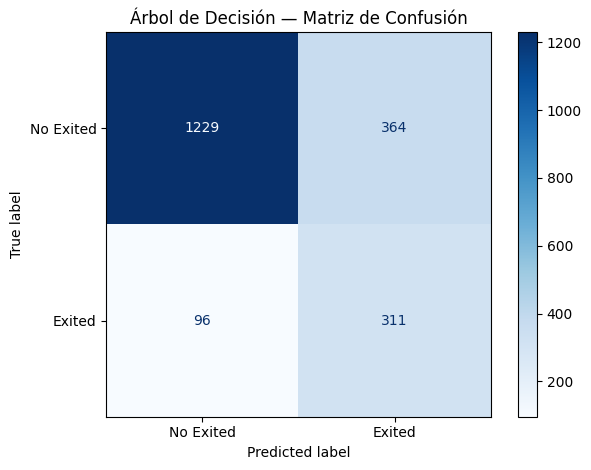

In [40]:
param_grid_dt = {
    "max_depth":        [3, 5, 10, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight":     ["balanced"],
}

gs_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_dt.fit(X_train, y_train)
best_dt = gs_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

results["Árbol de Decisión"] = {
    "best_params": gs_dt.best_params_,
    "accuracy":    accuracy_score(y_test, y_pred_dt),
    "precision":   precision_score(y_test, y_pred_dt),
    "recall":      recall_score(y_test, y_pred_dt),
    "f1":          f1_score(y_test, y_pred_dt),
    "roc_auc":     roc_auc_score(y_test, y_prob_dt),
}

print("── Árbol de Decisión ───────────────────────────────")
print("Mejores parámetros:", gs_dt.best_params_)
print(f"Accuracy en test : {results['Árbol de Decisión']['accuracy']:.4f}")
print(f"Precision en test : {results['Árbol de Decisión']['precision']:.4f}")
print(f"Recall en test    : {results['Árbol de Decisión']['recall']:.4f}")
print(f"F1-Score en test  : {results['Árbol de Decisión']['f1']:.4f}")
print(f"AUC-ROC en test   : {results['Árbol de Decisión']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_dt, target_names=["No Exited", "Exited"]))

ConfusionMatrixDisplay.from_estimator(
    best_dt, X_test, y_test,
    display_labels=["No Exited", "Exited"], cmap="Blues"
)
plt.title("Árbol de Decisión — Matriz de Confusión")
plt.tight_layout()
plt.show()

# Random Forest


── Random Forest ───────────────────────────────────
Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Accuracy en test : 0.8405
Precision en test : 0.5978
Recall en test    : 0.6609
F1-Score en test  : 0.6278
AUC-ROC en test   : 0.8604
              precision    recall  f1-score   support

   No Exited       0.91      0.89      0.90      1593
      Exited       0.60      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



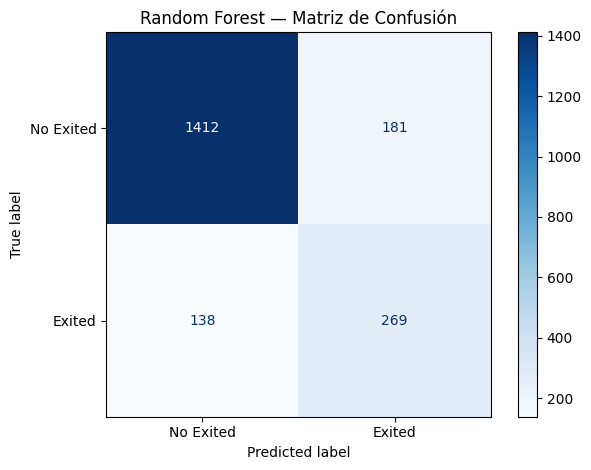

In [41]:
param_grid_rf = {
    "n_estimators":     [100, 300],
    "max_depth":        [5, 10, None],
    "min_samples_split":[2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight":     ["balanced"],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

results["Random Forest"] = {
    "best_params": gs_rf.best_params_,
    "accuracy":    accuracy_score(y_test, y_pred_rf),
    "precision":   precision_score(y_test, y_pred_rf),
    "recall":      recall_score(y_test, y_pred_rf),
    "f1":          f1_score(y_test, y_pred_rf),
    "roc_auc":     roc_auc_score(y_test, y_prob_rf),
}

print("── Random Forest ───────────────────────────────────")
print("Mejores parámetros:", gs_rf.best_params_)
print(f"Accuracy en test : {results['Random Forest']['accuracy']:.4f}")
print(f"Precision en test : {results['Random Forest']['precision']:.4f}")
print(f"Recall en test    : {results['Random Forest']['recall']:.4f}")
print(f"F1-Score en test  : {results['Random Forest']['f1']:.4f}")
print(f"AUC-ROC en test   : {results['Random Forest']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["No Exited", "Exited"]))

ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test,
    display_labels=["No Exited", "Exited"], cmap="Blues"
)
plt.title("Random Forest — Matriz de Confusión")
plt.tight_layout()
plt.show()

# XGBoost (Gradient Boosting)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\ignac\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
── XGBoost ─────────────────────────────────────────
Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Accuracy en test : 0.7960
Precision en test : 0.4992
Recall en test    : 0.7494
F1-Score en test  : 0.5992
AUC-ROC en test   : 0.8677
              precision    recall  f1-score   support

   No Exited       0.93      0.81      0.86      1593
      Exited       0.50      0.75      0.60       407

    accuracy                           0.80      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.80      0.81      2000



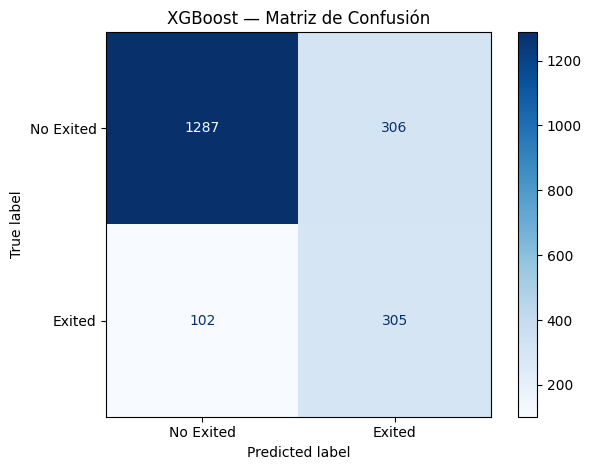

In [47]:
%pip install xgboost -q
from xgboost import XGBClassifier

# scale_pos_weight = ratio de negativos / positivos → compensa el desbalanceo
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos

param_grid_xgb = {
    "n_estimators":  [100, 300],
    "max_depth":     [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample":     [0.8, 1.0],
}

gs_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=spw, use_label_encoder=False,
                  eval_metric="logloss", random_state=42),
    param_grid_xgb, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_xgb.fit(X_train, y_train)
best_xgb = gs_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

results.pop("MLP", None)
results["XGBoost"] = {
    "best_params": gs_xgb.best_params_,
    "accuracy":    accuracy_score(y_test, y_pred_xgb),
    "precision":   precision_score(y_test, y_pred_xgb),
    "recall":      recall_score(y_test, y_pred_xgb),
    "f1":          f1_score(y_test, y_pred_xgb),
    "roc_auc":     roc_auc_score(y_test, y_prob_xgb),
}

print("── XGBoost ─────────────────────────────────────────")
print("Mejores parámetros:", gs_xgb.best_params_)
print(f"Accuracy en test : {results['XGBoost']['accuracy']:.4f}")
print(f"Precision en test : {results['XGBoost']['precision']:.4f}")
print(f"Recall en test    : {results['XGBoost']['recall']:.4f}")
print(f"F1-Score en test  : {results['XGBoost']['f1']:.4f}")
print(f"AUC-ROC en test   : {results['XGBoost']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=["No Exited", "Exited"]))

ConfusionMatrixDisplay.from_estimator(
    best_xgb, X_test, y_test,
    display_labels=["No Exited", "Exited"], cmap="Blues"
)
plt.title("XGBoost — Matriz de Confusión")
plt.tight_layout()
plt.show()

# SVM (Support Vector Machine)


── SVM ─────────────────────────────────────────────
Mejores parámetros: {'C': 1, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}
Accuracy en test : 0.7950
Precision en test : 0.4975
Recall en test    : 0.7420
F1-Score en test  : 0.5957
AUC-ROC en test   : 0.8596
              precision    recall  f1-score   support

   No Exited       0.92      0.81      0.86      1593
      Exited       0.50      0.74      0.60       407

    accuracy                           0.80      2000
   macro avg       0.71      0.78      0.73      2000
weighted avg       0.84      0.80      0.81      2000



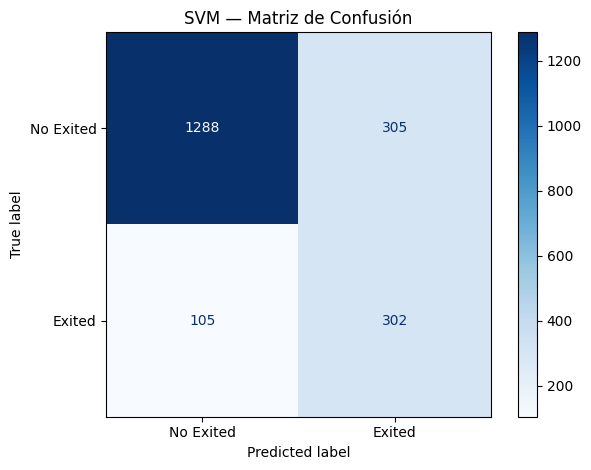

In [44]:
param_grid_svm = {
    "C":            [0.1, 1, 10],
    "kernel":       ["rbf", "linear"],
    "gamma":        ["scale", "auto"],
    "class_weight": ["balanced"],
}

gs_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_svm.fit(X_train, y_train)
best_svm = gs_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

results["SVM"] = {
    "best_params": gs_svm.best_params_,
    "accuracy":    accuracy_score(y_test, y_pred_svm),
    "precision":   precision_score(y_test, y_pred_svm),
    "recall":      recall_score(y_test, y_pred_svm),
    "f1":          f1_score(y_test, y_pred_svm),
    "roc_auc":     roc_auc_score(y_test, y_prob_svm),
}

print("── SVM ─────────────────────────────────────────────")
print("Mejores parámetros:", gs_svm.best_params_)
print(f"Accuracy en test : {results['SVM']['accuracy']:.4f}")
print(f"Precision en test : {results['SVM']['precision']:.4f}")
print(f"Recall en test    : {results['SVM']['recall']:.4f}")
print(f"F1-Score en test  : {results['SVM']['f1']:.4f}")
print(f"AUC-ROC en test   : {results['SVM']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_svm, target_names=["No Exited", "Exited"]))

ConfusionMatrixDisplay.from_estimator(
    best_svm, X_test, y_test,
    display_labels=["No Exited", "Exited"], cmap="Blues"
)
plt.title("SVM — Matriz de Confusión")
plt.tight_layout()
plt.show()

── Random Forest ───────────────────────────────────
Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Accuracy en test : 0.8405
Precision en test : 0.5978
Recall en test    : 0.6609
F1-Score en test  : 0.6278
AUC-ROC en test   : 0.8604
              precision    recall  f1-score   support

   No Exited       0.91      0.89      0.90      1593
      Exited       0.60      0.66      0.63       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.85      0.84      0.84      2000



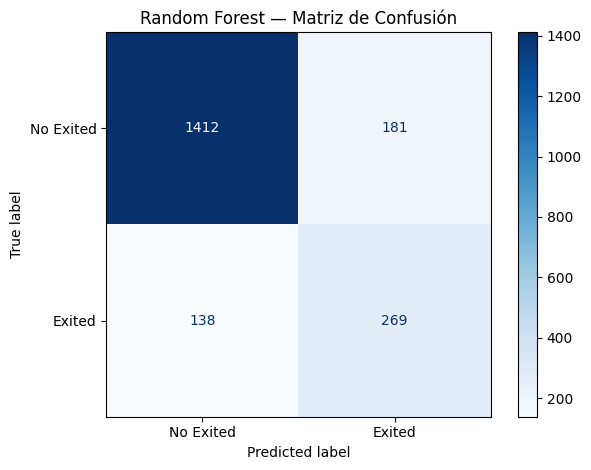

In [ ]:
param_grid_rf = {
    "n_estimators":     [100, 300],
    "max_depth":        [5, 10, None],
    "min_samples_split":[2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight":     ["balanced"],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_rf.fit(X_train, y_train)
best_rf = gs_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

results["Random Forest"] = {
    "best_params": gs_rf.best_params_,
    "accuracy":    accuracy_score(y_test, y_pred_rf),
    "precision":   precision_score(y_test, y_pred_rf),
    "recall":      recall_score(y_test, y_pred_rf),
    "f1":          f1_score(y_test, y_pred_rf),
    "roc_auc":     roc_auc_score(y_test, y_prob_rf),
}

print("── Random Forest ───────────────────────────────────")
print("Mejores parámetros:", gs_rf.best_params_)
print(f"Accuracy en test : {results['Random Forest']['accuracy']:.4f}")
print(f"Precision en test : {results['Random Forest']['precision']:.4f}")
print(f"Recall en test    : {results['Random Forest']['recall']:.4f}")
print(f"F1-Score en test  : {results['Random Forest']['f1']:.4f}")
print(f"AUC-ROC en test   : {results['Random Forest']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["No Exited", "Exited"]))

ConfusionMatrixDisplay.from_estimator(
    best_rf, X_test, y_test,
    display_labels=["No Exited", "Exited"], cmap="Blues"
)
plt.title("Random Forest — Matriz de Confusión")
plt.tight_layout()
plt.show()

# Red Neuronal (MLP)

── Red Neuronal (MLP) ──────────────────────────────
Optimizador: Adam
Mejores parámetros: {'activation': 'tanh', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001, 'max_iter': 300}
Accuracy en test : 0.8620
Precision en test : 0.8104
Recall en test    : 0.4201
F1-Score en test  : 0.5534
AUC-ROC en test   : 0.8631
              precision    recall  f1-score   support

   No Exited       0.87      0.97      0.92      1593
      Exited       0.81      0.42      0.55       407

    accuracy                           0.86      2000
   macro avg       0.84      0.70      0.74      2000
weighted avg       0.86      0.86      0.84      2000



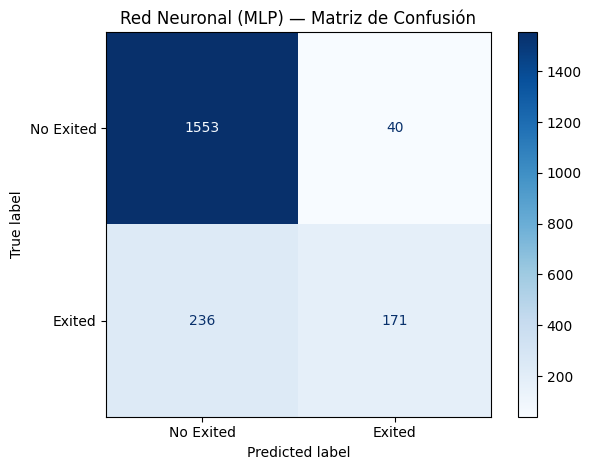

In [45]:
param_grid_mlp = {
    "hidden_layer_sizes": [(64,), (128,), (128, 64), (256, 128, 64)],
    "activation":         ["relu", "tanh"],
    "alpha":              [0.0001, 0.001, 0.01],   # regularización L2
    "learning_rate_init": [0.001, 0.01],
    "max_iter":           [300],
    "early_stopping":     [True],
}

gs_mlp = GridSearchCV(
    MLPClassifier(solver="adam", random_state=42),   # optimizador Adam
    param_grid_mlp, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0,
)
gs_mlp.fit(X_train, y_train)
best_mlp = gs_mlp.best_estimator_

y_pred_mlp = best_mlp.predict(X_test)
y_prob_mlp = best_mlp.predict_proba(X_test)[:, 1]

results["Red Neuronal (MLP)"] = {
    "best_params": gs_mlp.best_params_,
    "accuracy":    accuracy_score(y_test, y_pred_mlp),
    "precision":   precision_score(y_test, y_pred_mlp),
    "recall":      recall_score(y_test, y_pred_mlp),
    "f1":          f1_score(y_test, y_pred_mlp),
    "roc_auc":     roc_auc_score(y_test, y_prob_mlp),
}

print("── Red Neuronal (MLP) ──────────────────────────────")
print("Optimizador: Adam")
print("Mejores parámetros:", gs_mlp.best_params_)
print(f"Accuracy en test : {results['Red Neuronal (MLP)']['accuracy']:.4f}")
print(f"Precision en test : {results['Red Neuronal (MLP)']['precision']:.4f}")
print(f"Recall en test    : {results['Red Neuronal (MLP)']['recall']:.4f}")
print(f"F1-Score en test  : {results['Red Neuronal (MLP)']['f1']:.4f}")
print(f"AUC-ROC en test   : {results['Red Neuronal (MLP)']['roc_auc']:.4f}")
print(classification_report(y_test, y_pred_mlp, target_names=["No Exited", "Exited"]))

ConfusionMatrixDisplay.from_estimator(
    best_mlp, X_test, y_test,
    display_labels=["No Exited", "Exited"], cmap="Blues"
)
plt.title("Red Neuronal (MLP) — Matriz de Confusión")
plt.tight_layout()
plt.show()

# 5. Comparativa Final de Modelos


In [48]:
summary = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "roc_auc"]]
summary = summary.rename(columns={
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-Score",
    "roc_auc": "AUC-ROC",
})
summary = summary.sort_values("AUC-ROC", ascending=False)

summary

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
XGBoost,0.796,0.499182,0.749386,0.599214,0.867657
Red Neuronal (MLP),0.862,0.810427,0.420147,0.553398,0.863076
Random Forest,0.8405,0.597778,0.660934,0.627771,0.860409
SVM,0.795,0.497529,0.742015,0.595661,0.859641
Árbol de Decisión,0.77,0.460741,0.764128,0.574861,0.837711
Regresión Logística,0.72,0.394483,0.702703,0.5053,0.777127


El módelo óptimo para el problema churn que el trabajo se resuelve es el XGBoost:

En problemas de churn, donde la clase positiva es minoritaria y el coste de no detectar a un Cliente que abandona es especialmente elevado, se eligen AUC‑ROC y Recall como métricas fundamentales porque permiten evaluar con precisión la capacidad del modelo para discriminar entre clientes que abandonan y los que permanecen, independientemente del umbral de decisión, y porque garantizan que se identifiquen correctamente el mayor número posible de casos positivos. El AUC‑ROC mide la calidad global del modelo y su capacidad de ordenamiento a lo largo de todos los umbrales, mientras que el Recall asegura que se minimicen los falsos negativos, evitando pérdidas de clientes que tienen un impacto económico significativo. La combinación de ambas métricas proporciona una evaluación robusta y coherente con la naturaleza del problema y con las necesidades operativas del negocio.

# 6. Explicabilidad con SHAP y LIME 

### Problema 1: afectación de la estandarización a la interpretabilidad.

Resumen: Antes de proceder a la aplicación de ambas técnicas, se consideró necesario abordar una cuestión metodológica previa relacionada con la estandarización de las variables realizada durante la fase de Preprocesado de los datos e Ingeniería de características previa al modelado. Aunque esta transformación era adecuada y necesaria para el entrenamiento de los modelos, mantenerla en esta fase explicativa podía dificultar la interpretación de los resultados teniendo en cuenta que las explicaciones iban a estar expresadas en valores estandarizados, en z-socres, que resultarían muy poco intuitivos para negocio y, por tanto, de poca utilidad operativa.

### Problema 2: incompatibilidad a la hora de aplicar LIME.
-	Por un lado, LIME necesita trabajar con la escala original para poder generar perturbaciones y construir explicaciones comprensibles, dado que es en ese espacio donde los valores mantienen y conservan su significado real tal y como se pretende.

-	Por otro lado, el modelo solo puede producir predicciones válidas si recibe las variables en la escala estandarizada utilizada durante el entrenamiento, en caso contrario se estaría comprometiendo su capacidad predictiva.

Es decir, la inversión de la estandarización provocó una incompatibilidad entre ambos procesos dado que LIME operaba con los valores reales y el modelo con los estandarizados, con los z-scores.
Para resolverlo, para resolver esa incompatibilidad, lo que se implementó fue una función puente, un wrapper. De manera sucinta y sin entrar en detalles técnicos que no aplican al alcance de este trabajo: 

-	El wrapper recibe las perturbaciones generadas por LIME en escala real.
-	Estandariza las variables que fueron estandarizadas durante el preprocesado.
-	Envía esa versión transformada al modelo.
-	Este devuelve la probabilidad correspondiente. 
-	Y, con esa probabilidad, LIME ya construye la explicación local sobre los valores originales sin estandarizar.

En definitiva, el uso del wrapper permite poder aplicar LIME de manera técnicamente coherente y, al mismo tiempo, producir explicaciones que, como era el objetivo, resultan mucho más comprensibles y fácilmente interpretables para perfiles de negocio. El modelo recibe los datos en el formato que los necesita para poder predecir correctamente y, al mismo tiempo, las explicaciones se presentan en la escala que negocio puede interpretar de forma más clara. Como resultado, se obtienen explicaciones fiables, coherentes, comprensibles y operativamente útiles sin perder la validez técnica del proceso predictivo.




|  Cuál era la preocupación | Solución |
|---|---|
| Los plots mostrarían z-scores en lugar de valores reales y dificultaría la interpretabilidad| Se reconstruye la escala original con `scaler.inverse_transform` para **visualización** |
| LIME perturba en escala estandarizada → valores sin sentido | Se usa un **wrapper** que recibe valores originales, reescala solo las columnas necesarias y llama al modelo |


**Resultado:** los gráficos mostrarán `Age=45`, `CreditScore=650`, `Balance=125000`... en lugar de z-scores.

| Técnica | Qué muestra | Mejor para |
|---|---|---|
| **SHAP global** | Importancia media de cada variable en todo el test set | Comparar qué variables usa cada modelo |
| **SHAP beeswarm** | Importancia + dirección (¿alto Age → más churn?) | Entender el sentido de cada variable |
| **LIME local** | Por qué el modelo predijo ESO para UN cliente concreto | Explicar decisiones individuales |


## Setup — instalación y reconstrucción de escala original


In [ ]:
import subprocess, sys

for pkg in ["shap", "lime"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import shap
import numpy as np
from lime import lime_tabular

# ── Objetivo:  reconstruir escala original para visualización ─────────────────────
# Los modelos se entrenaron con datos estandarizados (correcto para LR, SVM, MLP).
# Para SHAP y LIME mostramos los valores ORIGINALES (CreditScore~650, Age~45...)
# aplicando inverse_transform solo sobre las columnas que estandarizamos.
X_test_display  = X_test.copy()
X_train_display = X_train.copy()
X_test_display[cols_to_scale]  = scaler.inverse_transform(X_test[cols_to_scale])
X_train_display[cols_to_scale] = scaler.inverse_transform(X_train[cols_to_scale])

feature_names = list(X_test.columns)

# ── Wrapper de predicción para LIME ───────────────────────────────────────────
# LIME perturba instancias en escala original → este wrapper reescala cols_to_scale
# antes de llamar al modelo, que espera datos estandarizados.
def make_predict_fn(model):
    def predict_fn(X_orig):
        X_df = pd.DataFrame(X_orig, columns=feature_names)
        X_scaled = X_df.copy()
        X_scaled[cols_to_scale] = scaler.transform(X_df[cols_to_scale])
        return model.predict_proba(X_scaled.values)
    return predict_fn

# ── Lista de modelos con tipo de explainer SHAP ────────────────────────────────
model_configs = [
    ("Regresión Logística", best_lr,  "linear"),
    ("Árbol de Decisión",   best_dt,  "tree"),
    ("Random Forest",       best_rf,  "tree"),
    ("XGBoost",             best_xgb, "tree"),
    ("SVM",                 best_svm, "kernel"),
    ("Red Neuronal (MLP)",  best_mlp, "kernel"),
]

print("Setup completado.")
print(f"Columnas en escala original para visualización: {cols_to_scale}")
print(f"Columnas sin modificar: {[c for c in feature_names if c not in cols_to_scale]}")


Setup completado.
Columnas en escala original para visualización: ['CreditScore', 'Balance', 'EstimatedSalary', 'Age', 'Tenure', 'NumOfProducts']
Columnas sin modificar: ['HasCrCard', 'IsActiveMember', 'Gender_Female', 'Gender_Male', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


# 6.1 SHAP — Importancia global de variables (todos los modelos)


![SHAP](TFM%20Images/SHAP.png)

  → Regresión Logística...

Background dataset has 8000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8000 when initializing the masker.


 ok
  → Árbol de Decisión... ok
  → Random Forest... ok
  → XGBoost... ok
  → SVM...

100%|██████████| 100/100 [07:08<00:00,  4.29s/it]

 ok
  → Red Neuronal (MLP)...


100%|██████████| 100/100 [00:03<00:00, 30.80it/s]


 ok


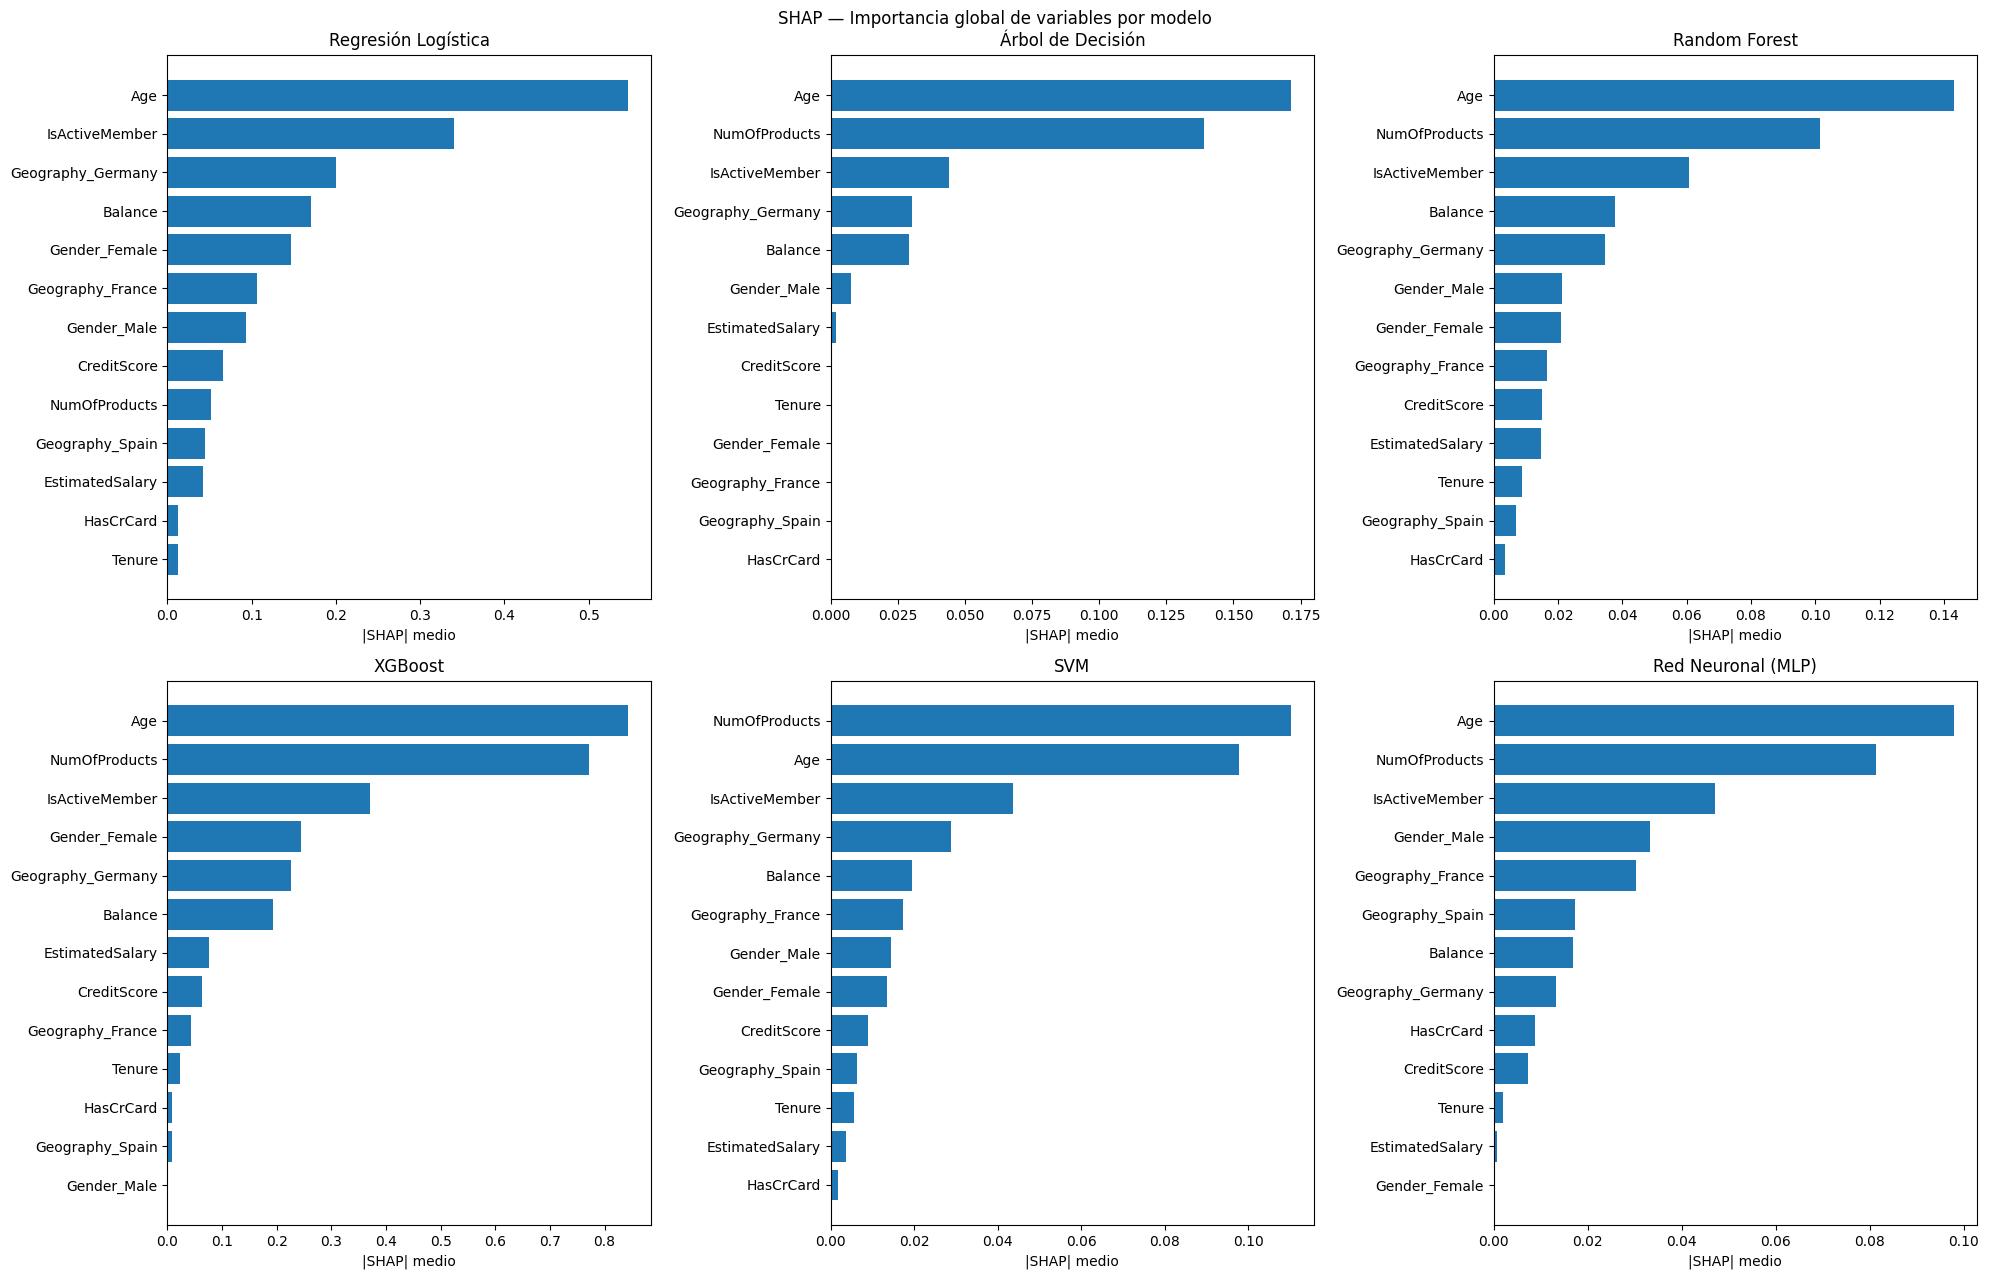

SHAP global completado.


In [33]:
# Explainers usados:
#   TreeExplainer   → DT, RF, XGBoost  (exacto, muy rápido)
#   LinearExplainer → Regresión Logística (exacto, instantáneo)
#   KernelExplainer → SVM, MLP (aproximado; usa 100 muestras test para ser manejable)

bg = shap.sample(X_train, 100, random_state=42)   # background para KernelExplainer
shap_store = {}   # guardamos para reusar en beeswarm

def compute_shap_class1(model, exp_type, X_eval):
    """Devuelve array (n_samples, n_features) de valores SHAP para Exited=1."""
    if exp_type == "tree":
        exp = shap.TreeExplainer(model)
        sv  = exp.shap_values(X_eval)
        if isinstance(sv, list):          # sklearn RF → [class0, class1]
            return np.array(sv[1]), exp
        if sv.ndim == 3:                  # algunas versiones XGB → (n, f, classes)
            return sv[:, :, 1], exp
        return np.array(sv), exp          # XGBoost binario → (n, f)
    elif exp_type == "linear":
        exp = shap.LinearExplainer(model, X_train)
        sv  = exp.shap_values(X_eval)
        if isinstance(sv, list):
            return np.array(sv[1]), exp
        return np.array(sv), exp
    else:   # kernel: aproximado, solo 100 muestras test
        predict_fn = lambda X: model.predict_proba(X)[:, 1]
        exp = shap.KernelExplainer(predict_fn, shap.sample(bg, 50, random_state=42))
        sv  = exp.shap_values(X_eval.iloc[:100], nsamples=300)
        if isinstance(sv, list):
            return np.array(sv[1]), exp
        return np.array(sv), exp

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

for ax, (name, model, exp_type) in zip(axes, model_configs):
    print(f"  → {name}...", end="", flush=True)
    sv, exp_obj = compute_shap_class1(model, exp_type, X_test)
    shap_store[name] = (sv, exp_obj, exp_type)

    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=feature_names).sort_values(ascending=True)
    ax.barh(mean_abs.index, mean_abs.values)
    ax.set_title(name)
    ax.set_xlabel("|SHAP| medio")
    print(" ok")

plt.suptitle("SHAP — Importancia global de variables por modelo")
plt.tight_layout()
plt.show()
print("SHAP global completado.")


# 6.2 SHAP Beeswarm — Dirección del efecto de cada variable

> Solo para modelos basados en árboles (TreeExplainer es exacto y rápido).  
> **Cómo leer el beeswarm:** cada punto es una muestra del test set.  
> - **Eje x**: valor SHAP positivo → aumenta P(Exited); negativo → la reduce  
> - **Color**: rojo = valor alto de la variable en escala original | azul = valor bajo


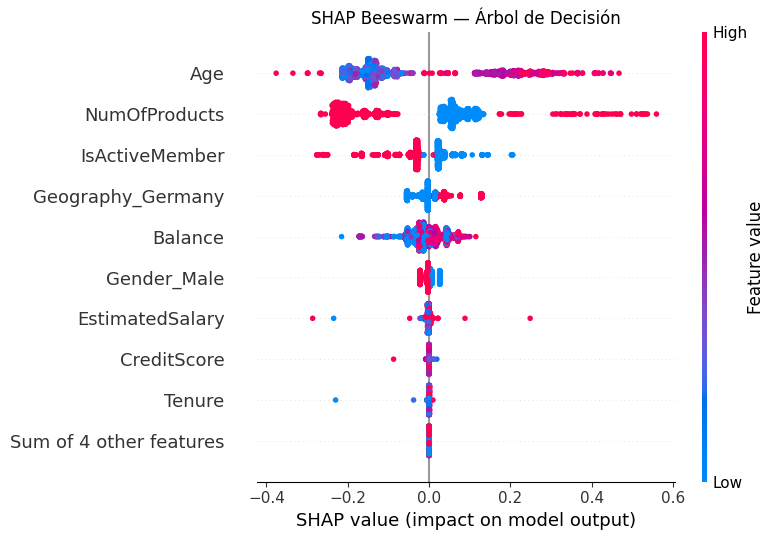

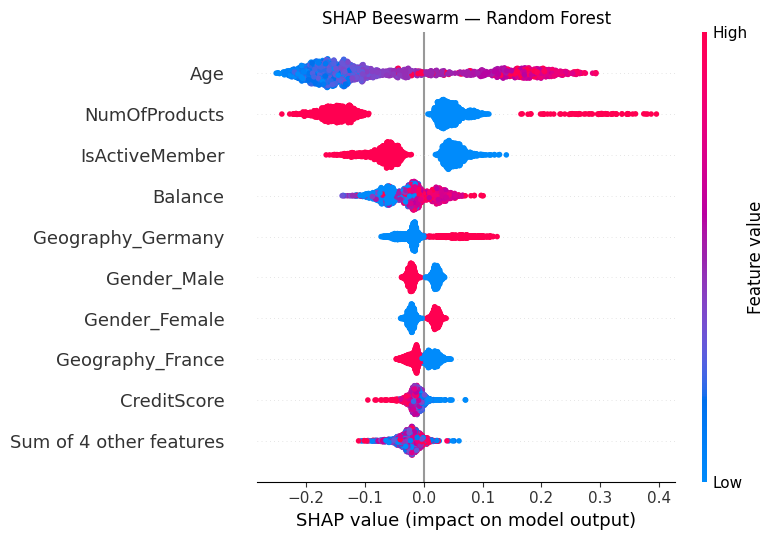

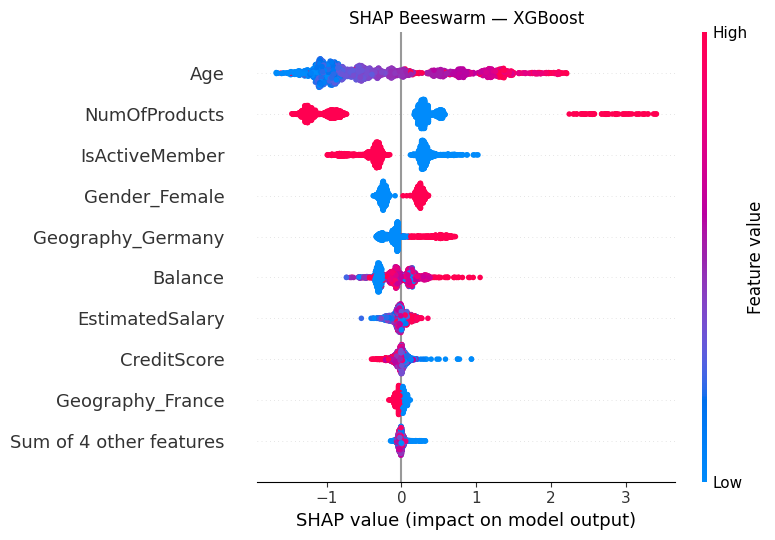

SHAP Beeswarm completado para DT, RF y XGBoost.


In [34]:
for name in ["Árbol de Decisión", "Random Forest", "XGBoost"]:
    sv, exp_obj, _ = shap_store[name]

    # expected_value puede ser un escalar (XGBoost) o una lista (sklearn RF)
    ev = exp_obj.expected_value
    base_val = float(ev[1] if hasattr(ev, "__len__") and len(ev) > 1 else ev)

    n = len(sv)   # tree models usan todo X_test

    # Pasar X_test_display como 'data' → beeswarm colorea con valores originales
    shap_exp = shap.Explanation(
        values        = sv[:n],
        base_values   = np.full(n, base_val),
        data          = X_test_display.values[:n],   # ← escala original
        feature_names = feature_names,
    )

    plt.figure(figsize=(9, 5))
    shap.plots.beeswarm(shap_exp, max_display=10, show=False)
    plt.title(f"SHAP Beeswarm — {name}")
    plt.tight_layout()
    plt.show()

print("SHAP Beeswarm completado para DT, RF y XGBoost.")


# 6.3 LIME — Explicación local por instancia (todos los modelos)

> Para cada modelo se muestran **2 clientes**: uno que abandona (Exited=1) y uno que no (Exited=0).

> Las barras muestran la **contribución de cada variable** a P(Exited=1): rojo = empuja hacia churn, azul = empuja hacia retención.  

> Los valores en las etiquetas son los valores **originales** del cliente (Age=45, CreditScore=650...).


![LIME](TFM%20Images/LIME.png)

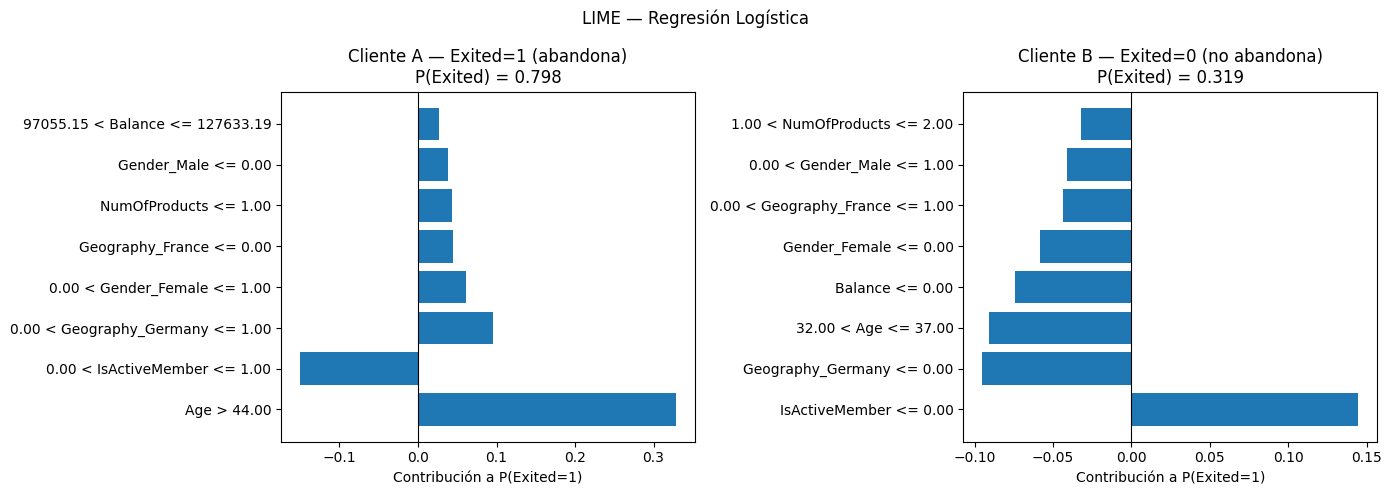

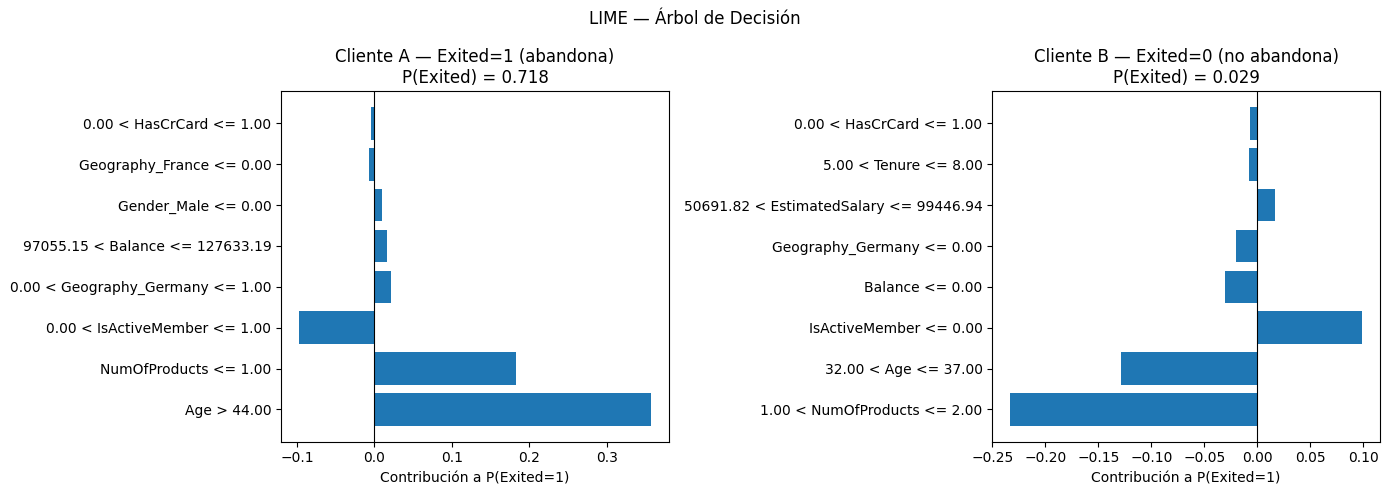

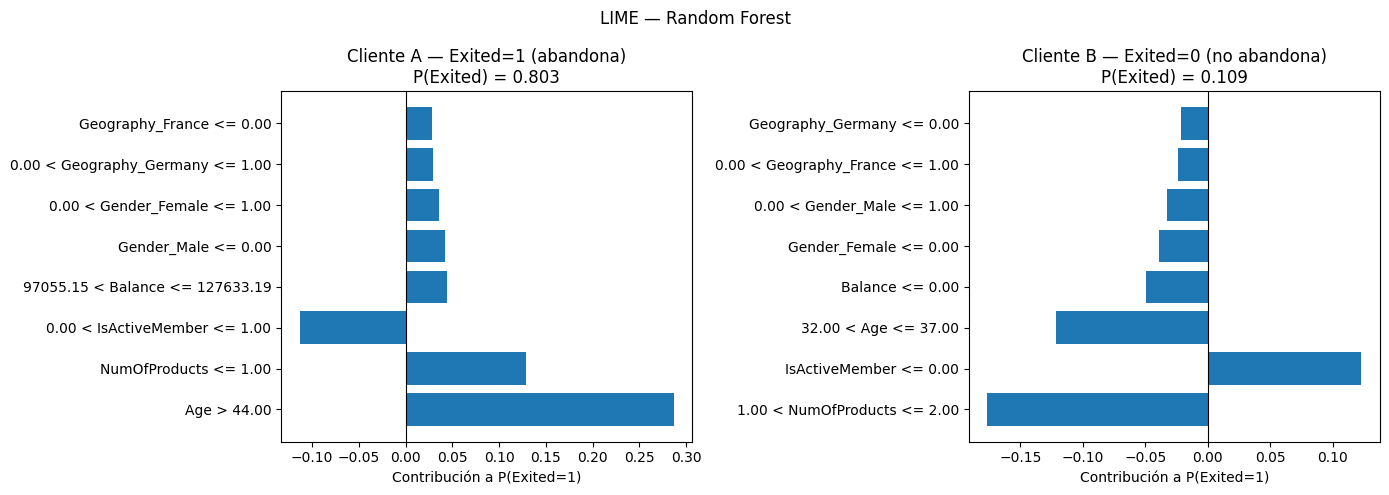

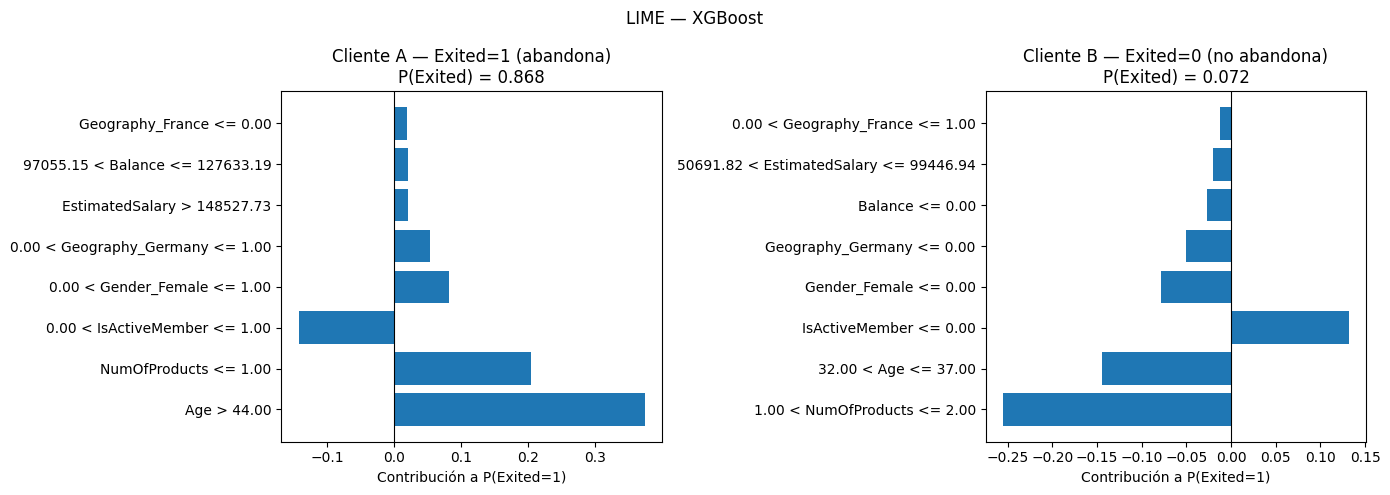

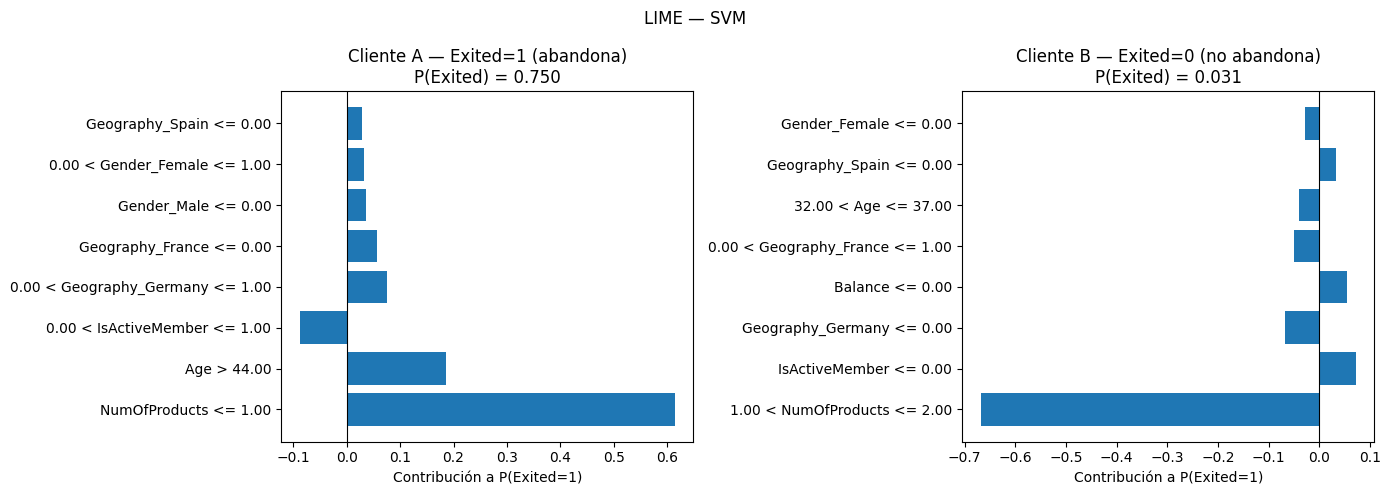

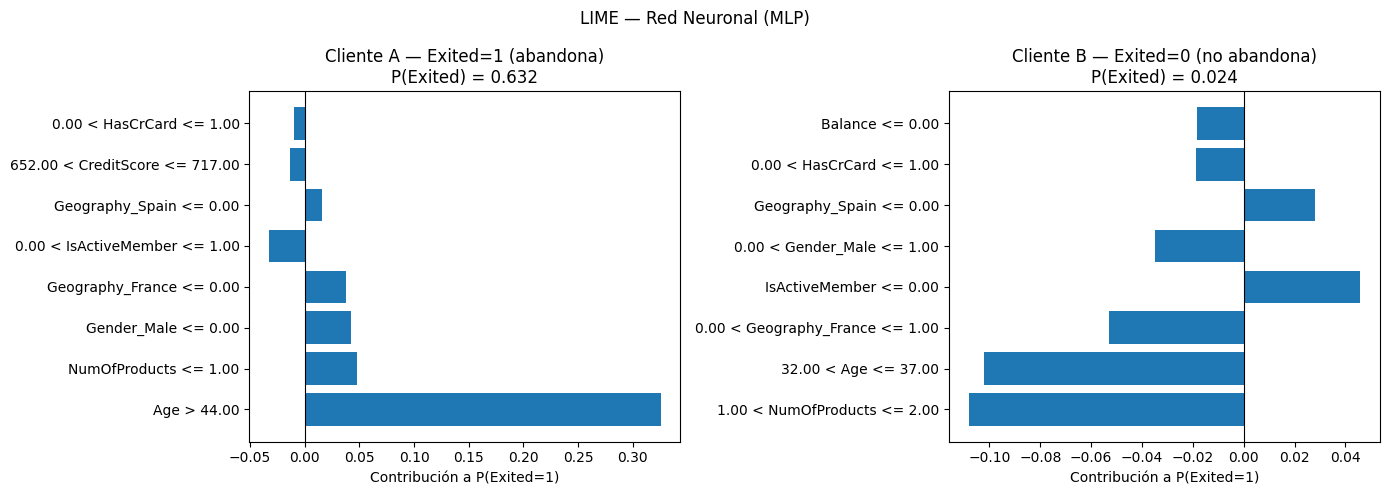

LIME completado para todos los modelos.


In [35]:
# ── Explainer LIME con X_train en escala ORIGINAL ────────────────────────────
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data = X_train_display.values,
    feature_names = feature_names,
    class_names   = ["No Exited", "Exited"],
    mode          = "classification",
    random_state  = 42,
)

# ── Seleccionar 2 instancias bien predichas por Random Forest ─────────────────
y_pred_rf_series = pd.Series(best_rf.predict(X_test), index=X_test.index)
idx_exited    = y_test[(y_test == 1) & (y_pred_rf_series == 1)].index[0]
idx_no_exited = y_test[(y_test == 0) & (y_pred_rf_series == 0)].index[0]
test_index    = list(X_test.index)

instances = [
    (idx_exited,    "Cliente A — Exited=1 (abandona)"),
    (idx_no_exited, "Cliente B — Exited=0 (no abandona)"),
]

# ── LIME para cada modelo ─────────────────────────────────────────────────────
for name, model, _ in model_configs:
    predict_fn = make_predict_fn(model)   # wrapper: recibe original, reescala internamente

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"LIME — {name}")

    for ax, (idx, label) in zip(axes, instances):
        pos      = test_index.index(idx)
        instance = X_test_display.values[pos]   # valores originales al explainer

        exp = lime_explainer.explain_instance(
            data_row     = instance,
            predict_fn   = predict_fn,
            num_features = 8,
            top_labels   = 2,
        )

        feat_weights = exp.as_list(label=1)   # explicación para clase Exited=1
        feat_labels  = [fw[0] for fw in feat_weights]
        feat_vals    = [fw[1] for fw in feat_weights]

        ax.barh(feat_labels, feat_vals)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{label}\nP(Exited) = {exp.predict_proba[1]:.3f}")
        ax.set_xlabel("Contribución a P(Exited=1)")

    plt.tight_layout()
    plt.show()

print("LIME completado para todos los modelos.")
